# Julia notebook to compute the buoyancy field using the 1D vertical diffusion equation, inspired by Peterson & Callies (2025, in review) theory.

twnh Sep '25

This notebook solves the steady vertical diffusion problem with a Green's function.

The problem is to solve:
\begin{align}
\frac{\partial }{\partial z} \left(\kappa(z)  \frac{db}{dz} \right)
    + B(z) & = 0 , \\
\frac{\partial }{\partial z} \left(\kappa_0 + \exp \left( - \alpha (z + H ) \right)  \frac{db}{dz} \right)
    + B(z) & = 0 , \\
\left[ \kappa_{0} + \exp \left( -\alpha(z + H) \right) \right] \frac{d^2 b}{dz^2}
    - \alpha \exp \left( -\alpha(z + H) \right) \frac{db}{dz}
    + B(z) & = 0 ,
\end{align}
for $b(z)$, given forcing function $B(z)$, with boundary conditions
\begin{align}
 \frac{db}{dz}  &= \beta \text{~ at~} z = -H , \\
 b &= 0 \text{~ at~} z = 0 .
\end{align}

This problem is solved repeatedly for different $H(x)$ fields and $B(x,z)$ fields. This constructs a buoyancy field that varies in $(x,z)$ using the 1D diffusion equation.

See also: ``DiffusionEquationSolution.ipynb`` for the G's function solution to the 1D buoyancy equation.

### Approach: Solve the Green's function problem first:

\begin{equation}
0 = \left[ \kappa_{0} + \exp \left( -\alpha(z + H) \right) \right] \frac{d^2 G}{dz^2}
    - \alpha \exp \left( -\alpha(z + H) \right) \frac{d G}{dz}
    + \delta(z - \xi) ,
\end{equation}
for $G(z; \xi)$ with boundary conditions
\begin{align}
 \left. \frac{dG}{dz} \right|_{z = -H} = 0 , \\
 G(0; \xi) = 0.
\end{align}
The ODE can be rearranged as:
\begin{equation}
0 = \frac{d }{dz} \left[ 
    \kappa(z) \frac{d G}{dz} \right]
    + \delta(z - \xi) ,
\end{equation}
for $\kappa = \kappa_0 + \exp \left( -\alpha(z + H) \right)$.


### Solution:

Construct $G(z; \xi)$ either side of the point $\xi$:

1. Solve for $G_- (z)$ on $-H \le z \le \xi$, such that

\begin{equation}
\frac{d }{dz} \left[ \kappa(z) \frac{d G_-}{dz} \right] = 0,
\end{equation}

with boundary condition

\begin{equation}
 \left. \frac{dG_-}{dz} \right|_{z = -H} = 0 ,
\end{equation}

2. Solve for $G_+ (z)$ on $\xi \le z \le 0$, such that

\begin{equation}
\frac{d }{dz} \left[ \kappa(z) \frac{d G_+}{dz} \right] = 0,
\end{equation}

with boundary condition

\begin{equation}
 G_+ (0) = 0 .
\end{equation}

3. Compute the Wronskian of $G_-(z)$ and $G_+(z)$:

\begin{equation}
W(z) = \left| 
\begin{matrix} 
G_-(z) & G_+ (z) \\
G_-'(z) & G_+' (z) 
\end{matrix} \right| .
\end{equation}

4. Write the Green's function as

\begin{align}
G(z; \xi) = \begin{cases}
\displaystyle \frac{G_-(z) G_+(\xi)}{\kappa (\xi) W(\xi)} &\text{\normalsize~~for~} -H \le z \le \xi \\
\displaystyle \frac{G_+(z) G_-(\xi)}{\kappa (\xi) W(\xi)} &\text{\normalsize~~for~} \xi \le z \le 0 
\end{cases} .
\end{align}


5. Solve the original problem using $G(z; \xi)$:

\begin{equation}
b(z) = \int_{-H}^{0} G(z; \xi) B(\xi) \; d \xi + \beta G(z,-H) .
\end{equation}

In [1]:
using SymPy

Define symbols and functions

In [2]:
κ₀, α, H = symbols("κ₀ α H β", real=true, positive=true)
z, ξ, A  = symbols("z ξ A",    real=true)
b        = SymFunction("b")
B           = symbols("B", cls=SymFunction)
# β        = symbols("β",    real=true)
im       = SymPy.im  # SymPy's imaginary unit

# Define diffusivity profile here:
κ = κ₀                             # Constant viscosity profile
# κ = κ₀ + exp(-α*(z+H))               # Bottom-intensified viscosity profile

# Define the $B(z)$ source term here:
B = z                                # Linear profile with vanishing surface buoyancy

z

Define the ODE:

In [3]:
ode = Eq(κ * diff(b(z),z), A)


   d           
κ₀*--(b(z)) = A
   dz          

1. Solve for $G_- (z)$ on $-H \le z \le \xi$,

In [4]:
bm = dsolve(ode.subs(A,0), b(z)).rhs
@assert simplify(diff(bm,z).subs(z,-H)) == 0              # Check Neumann BC at bottom
display(bm)

C1

2. Solve for $G_+(z)$ on  $\xi \le z \le 0$

In [5]:
bp = dsolve(ode, b(z), ics = Dict(b(0)=>0) ).rhs
@assert simplify(bp.subs(z,0)) == 0                      # Check Dirichlet BC at top
display(bp)

A*z
---
κ₀ 

3. Compute Wronskian $W(z)$:

In [6]:
W = simplify(bm * diff(bp, z) - bp * diff(bm, z))

A*C1
----
 κ₀ 

4. Compute Green's function $G(z; \xi)$:

In [7]:
Gm = simplify(bm * bp.subs(z,ξ) / (κ.subs(z,ξ) * W.subs(z,ξ)))
Gp = simplify(bm.subs(z,ξ) * bp / (κ.subs(z,ξ) * W.subs(z,ξ)))

# Check continuity and jump condition:
@assert Gm.subs(z,ξ) - Gp.subs(z,ξ) == 0
@assert simplify(diff(Gm, z).subs(z,ξ) - diff(Gp, z).subs(z,ξ)) + 1/κ.subs(z,ξ) == 0

# Define piecewise Green's function:
G = simplify(sympy.Piecewise((Gm, Le(z,ξ)), (Gp, Ge(z,ξ))))

# Check boundary conditions are satisfied
@assert simplify(diff(G,z).subs(z,-H).subs(ξ,-H/2)) == 0
@assert simplify(G.subs(z,0).subs(ξ,-H/2)) == 0

display(G)

/ξ             
|--  for z <= ξ
|κ₀            
<              
|z             
|--  for z >= ξ
\κ₀            

5. Solve the original problem using $G(z; \xi)$:

In [8]:
b = integrate( G * B.subs(z,ξ), (ξ,-H,0) )
display(simplify(b))

   2                         2                     3
  H *z   z*Min(0, Max(-H, z))    Min(0, Max(-H, z)) 
- ---- + --------------------- - -------------------
   2               2                      3         
----------------------------------------------------
                         κ₀                         

Make plot of Green's function for sample parameters

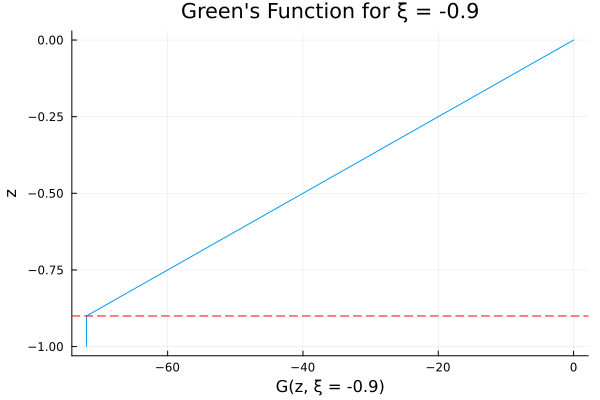

In [9]:
using Plots

# Pick the value of ξ in [-H, 0]:
ξᵢ     = -0.9
α_val  = 8.0
H_val  = 1.0
κ₀_val = 0.0125

# Insert parameter values here and convert symbolic G to a function:
G_fixed(zᵢ,ξᵢ)  = G.subs([(κ₀, κ₀_val), (α, α_val), (H, H_val), (ξ, ξᵢ), (z, zᵢ)])

# --- Plot ---
zvals = range(-1, 0, length=512)
Gvals = [G_fixed(z_, ξᵢ) |> float for z_ in zvals]  # use float() to get a number
plot(Gvals, zvals, ylabel="z", xlabel="G(z, ξ = $ξᵢ)", title="Green's Function for ξ = $ξᵢ", legend=false)
hline!([ξᵢ], label="ξ", linestyle=:dash, color=:red)

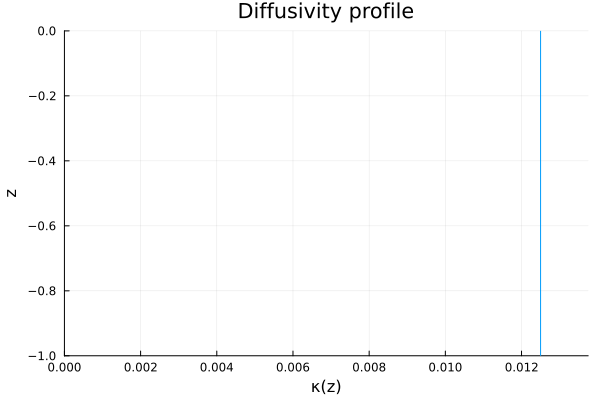

In [16]:
κ_fixed(zᵢ) = κ.subs([(κ₀, κ₀_val), (α, α_val), (H, H_val), (z, zᵢ)])
κvals = [κ_fixed(z_) |> float for z_ in zvals]
plot( κvals, zvals, label="κ(z)", ylabel="z", xlabel="κ(z)", title="Diffusivity profile", legend=false, xlims=(0,maximum(κvals) * 1.1), ylims=(-H_val,0) )

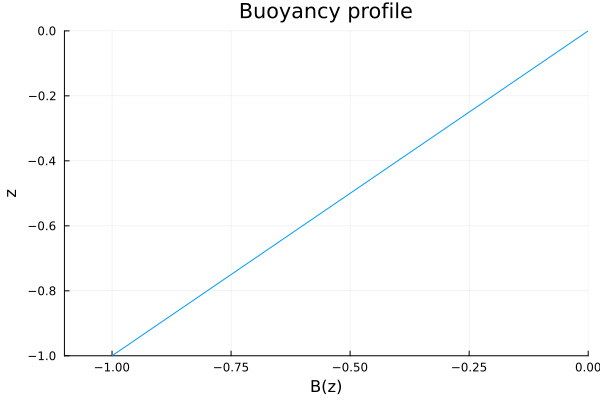

In [14]:
B_fixed(zᵢ) = B.subs([(z, zᵢ)])
Bvals = [B_fixed(z_) |> float for z_ in zvals]
plot( Bvals, zvals, label="B(z)", ylabel="z", xlabel="B(z)", title="Buoyancy profile", legend=false, xlims=(minimum(Bvals) * 1.1,maximum(Bvals) * 1.1), ylims=(-H_val,0) )

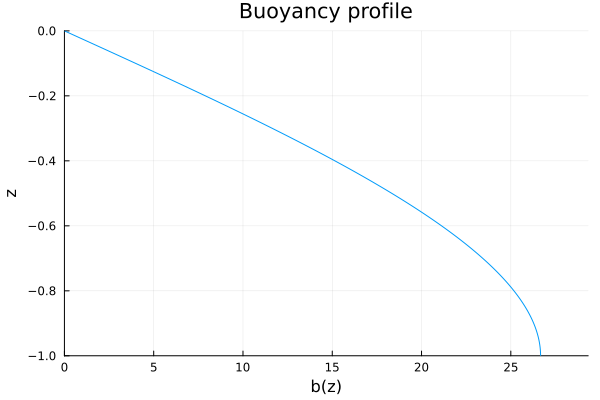

In [15]:
b_fixed(zᵢ) = b.subs([(κ₀, κ₀_val), (α, α_val), (H, H_val), (z, zᵢ)])
bvals = [b_fixed(z_) |> float for z_ in zvals]
plot( bvals, zvals, label="b(z)", ylabel="z", xlabel="b(z)", title="Buoyancy profile", legend=false, xlims=(minimum(bvals),maximum(bvals) * 1.1), ylims=(-H_val,0) )